<a href="https://colab.research.google.com/github/Raha11Muhammed/SmartPhone-dataSet/blob/main/Smartphone_Benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
mydata = pd.read_csv('SmartPhone_Benchmark.csv')

In [ ]:
mydata.head(5)

,model,price,rating,ram_gb,storage_gb
0,oneplus 11 5g,54999,89.0,12,12
1,oneplus nord ce 2 lite 5g,19989,81.0,6,6
2,samsung galaxy a14 5g,16499,75.0,4,4
3,motorola moto g62 5g,14999,81.0,6,6
4,realme 10 pro plus,24999,82.0,6,6


In [ ]:
mydata.tail(5)

,model,price,rating,ram_gb,storage_gb
495,xiaomi redmi 11 prime,11600,74.0,4,4
496,realme c31,8299,62.0,3,3
497,motorola moto g31,11999,78.0,6,6
498,samsung galaxy z flip 4 5g,89999,88.0,8,8
499,oneplus 6,27999,77.0,8,8


In [ ]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   model       500 non-null    object 
 1   price       500 non-null    int64  
 2   rating      500 non-null    float64
 3   ram_gb      500 non-null    int64  
 4   storage_gb  500 non-null    int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 19.7+ KB


In [ ]:
mydata.describe()

,price,rating,ram_gb,storage_gb
count,500.000000,500.000000,500.000000,500.000000
mean,32772.160000,79.354000,8.840000,8.840000
std,40962.204232,6.462524,32.041969,32.041969
min,2999.000000,60.000000,1.000000,1.000000
25%,13999.000000,76.000000,4.000000,4.000000
50%,20990.000000,80.000000,6.000000,6.000000
75%,36124.000000,84.000000,8.000000,8.000000
max,650000.000000,89.000000,512.000000,512.000000


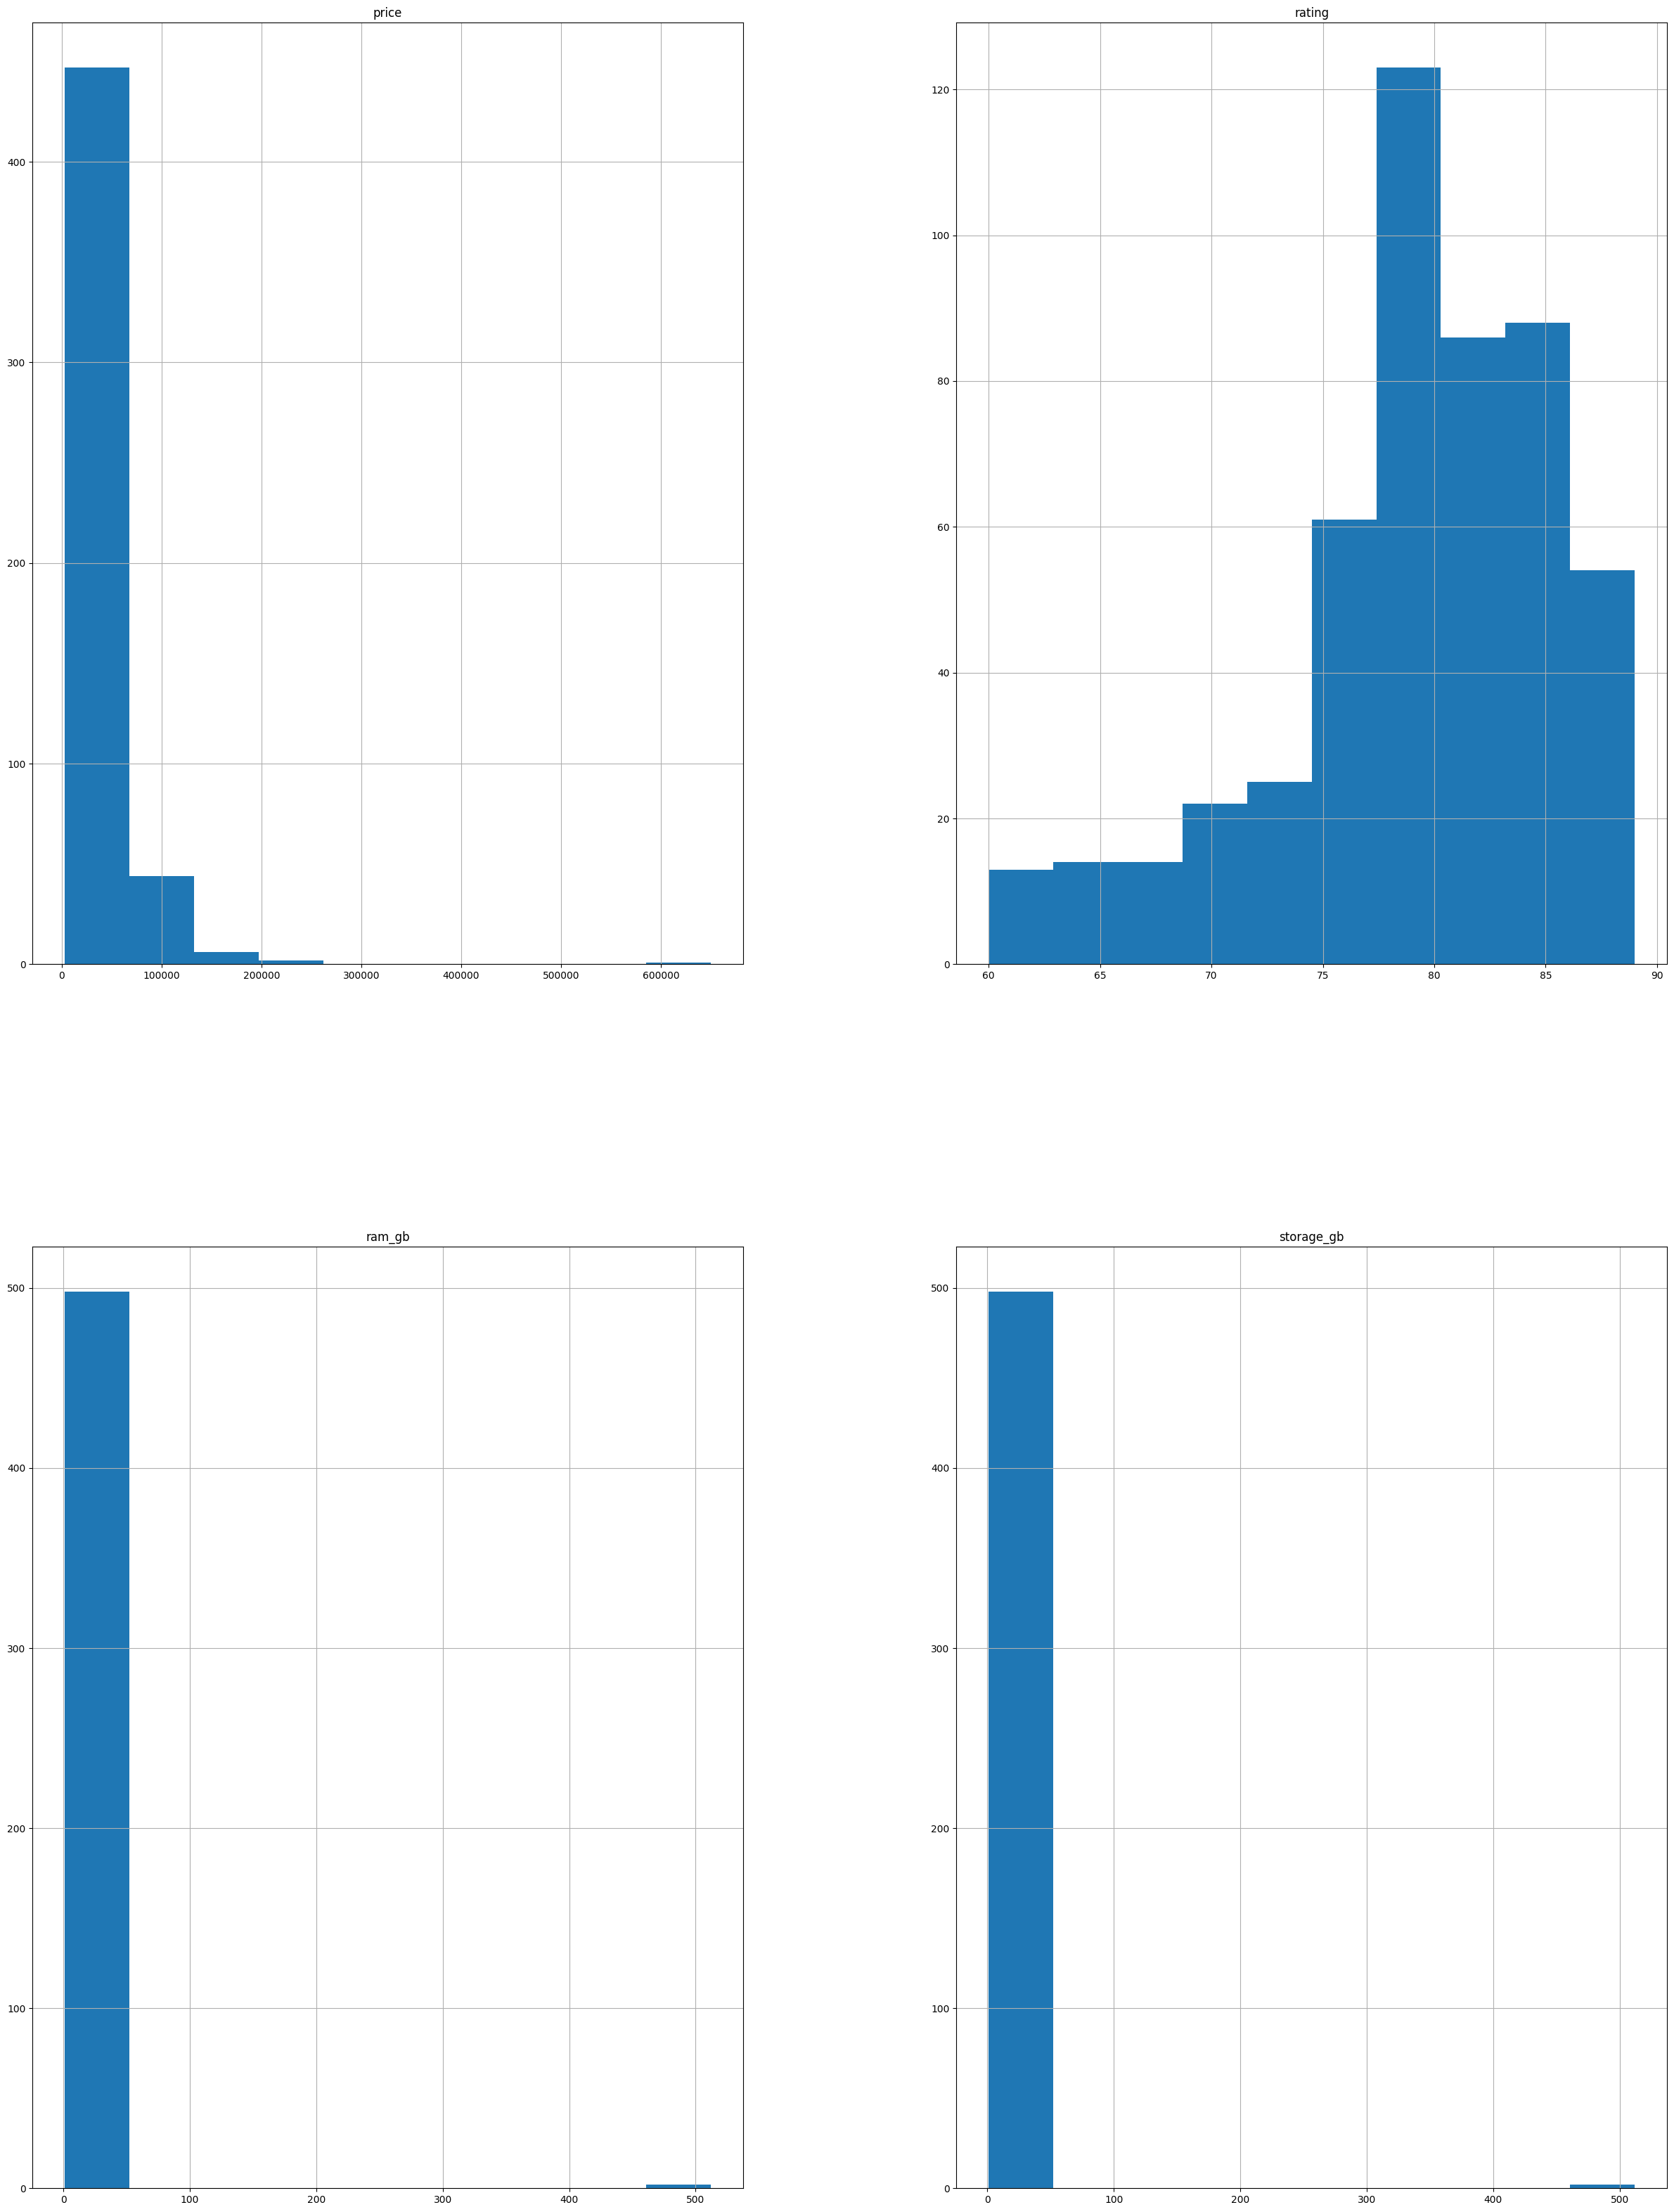

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

mydata.hist(figsize=(30,40))
plt.show()

Text(0, 0.5, 'Count')

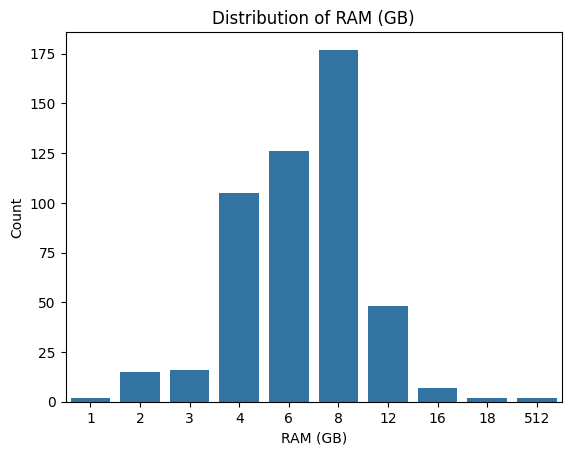

In [ ]:
sns.countplot(x="ram_gb", data=mydata)
plt.title('Distribution of RAM (GB)')
plt.xlabel('RAM (GB)')
plt.ylabel('Count')

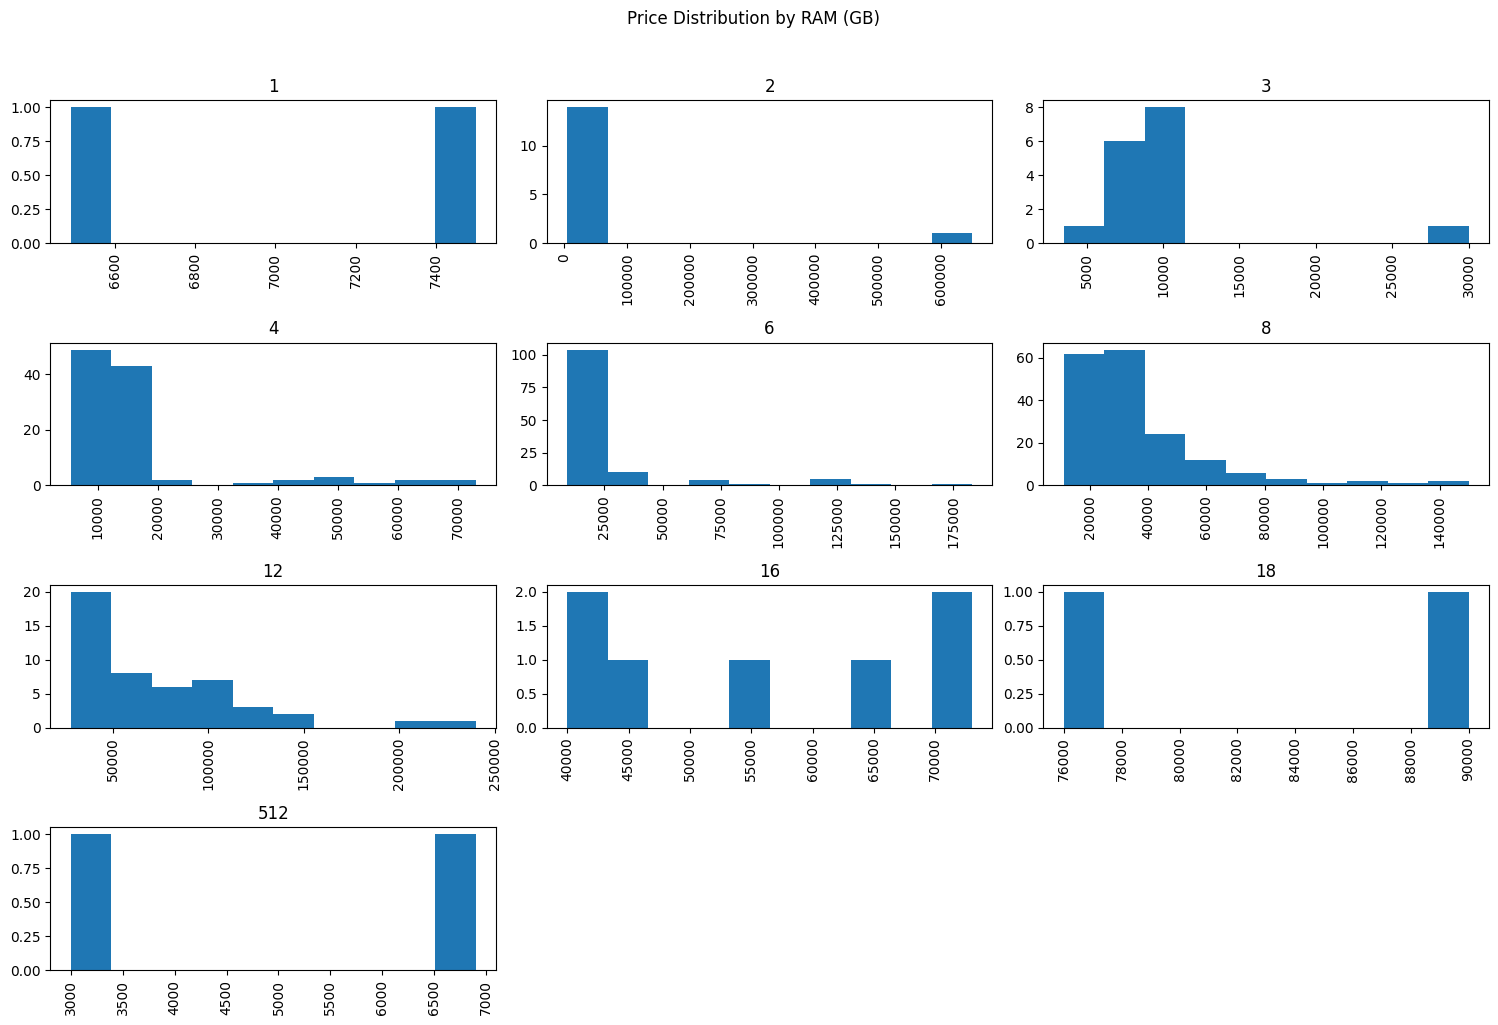

In [ ]:
mydata.hist(by='ram_gb', column='price', figsize=(15, 10))
plt.suptitle('Price Distribution by RAM (GB)', y=1.02) # Add a main title for the figure
plt.tight_layout()
plt.show()

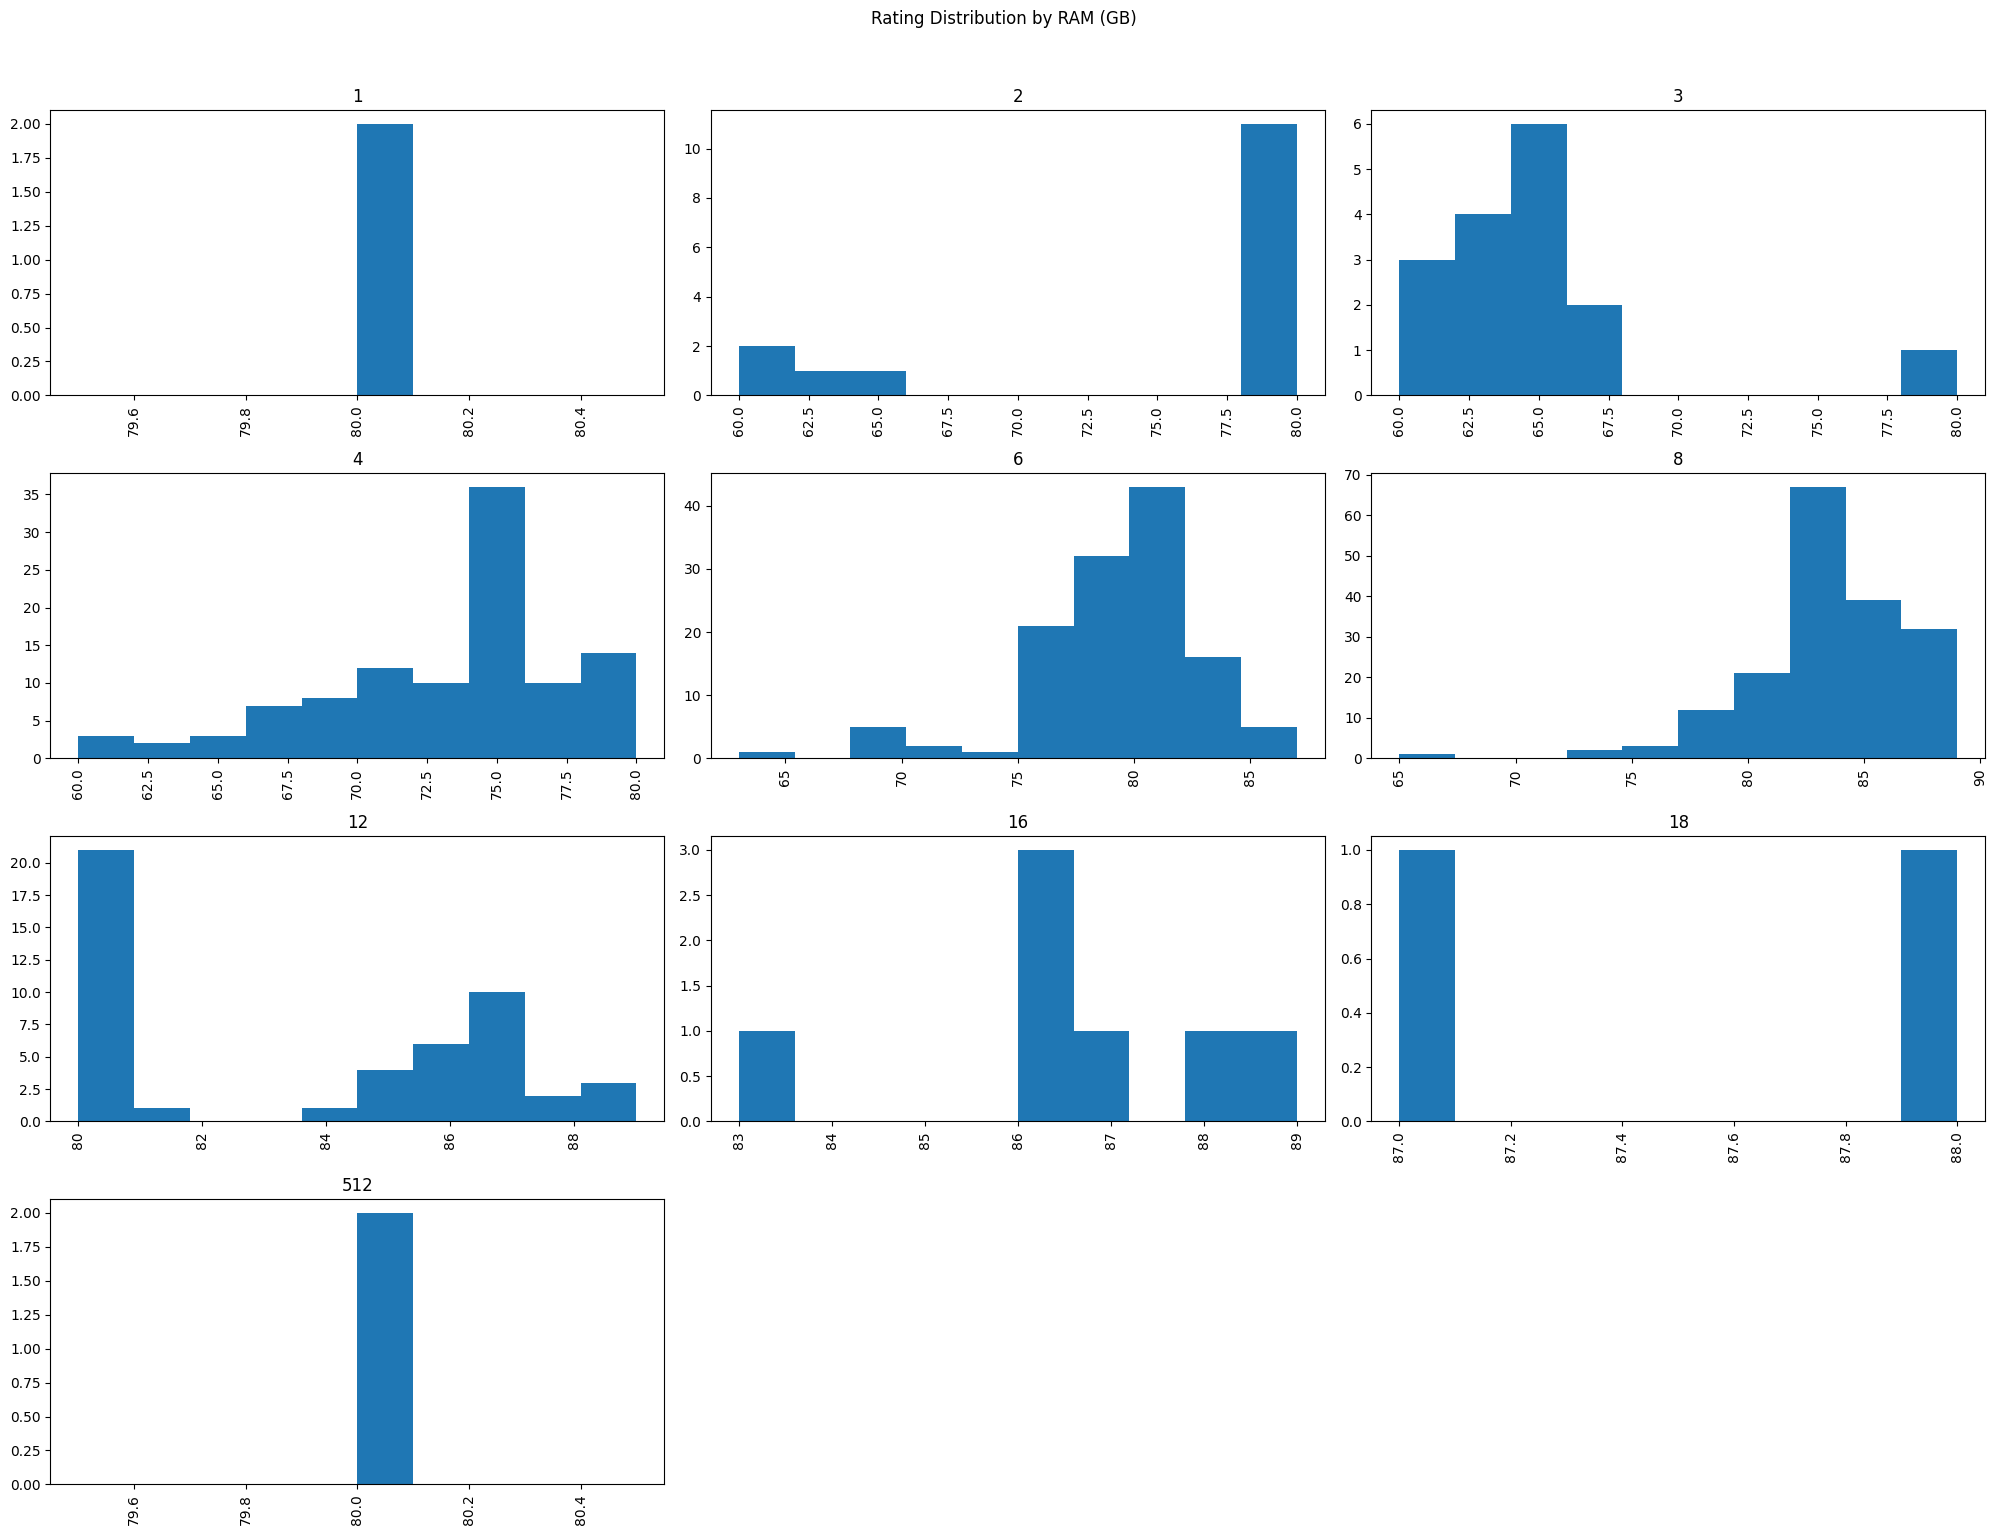

In [ ]:
mydata.hist(by='ram_gb', column='rating', figsize=(20, 15))
plt.suptitle('Rating Distribution by RAM (GB)', y=1.02)
plt.tight_layout()
plt.show()

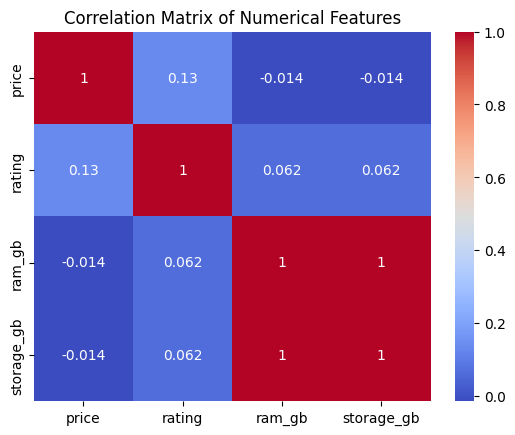

In [ ]:
corr_matrix = mydata.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

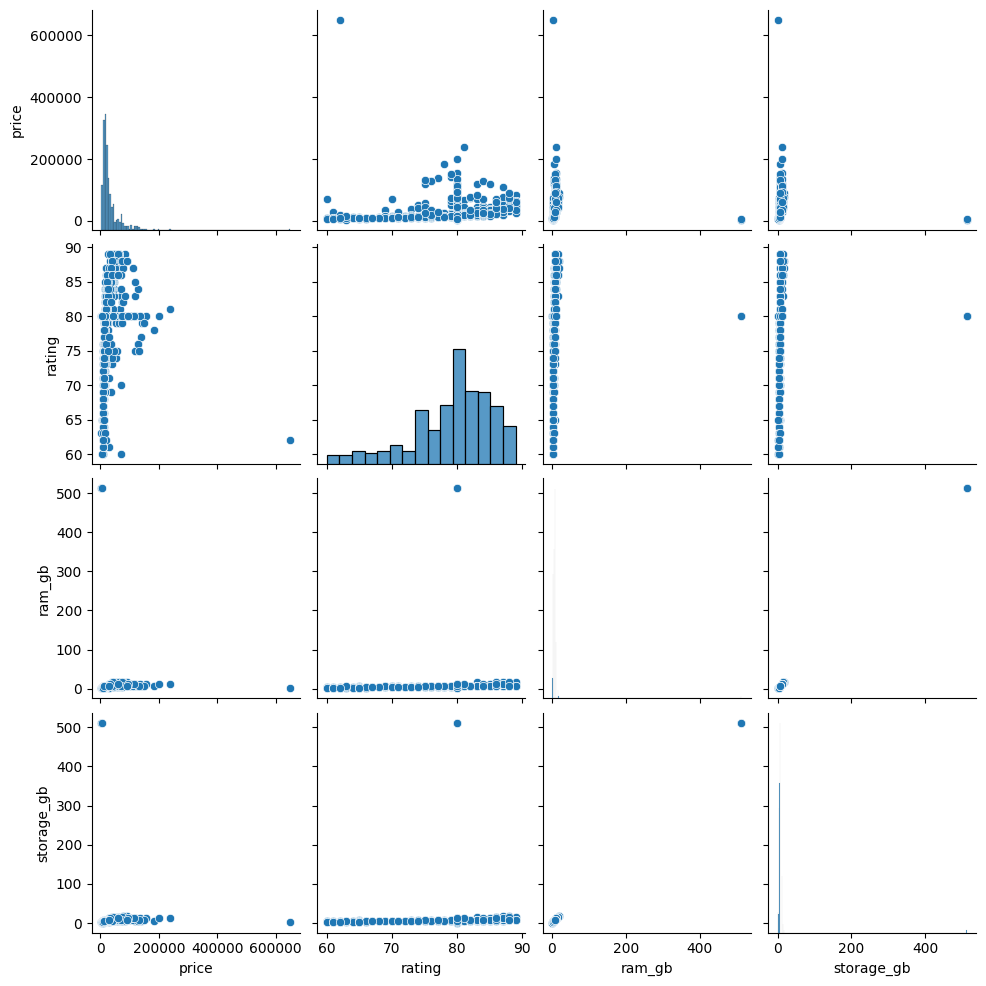

In [ ]:
sns.pairplot(mydata)

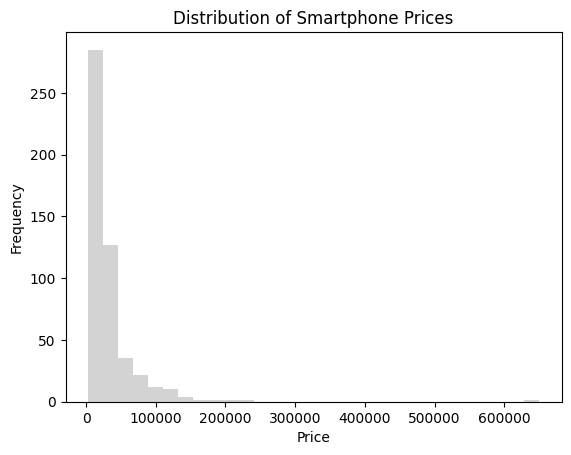

In [ ]:
fig, ax = plt.subplots()
_ = plt.hist(mydata['price'], color='lightgray', bins=30) # Using 'price' column and setting bins for better visualization
plt.title('Distribution of Smartphone Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

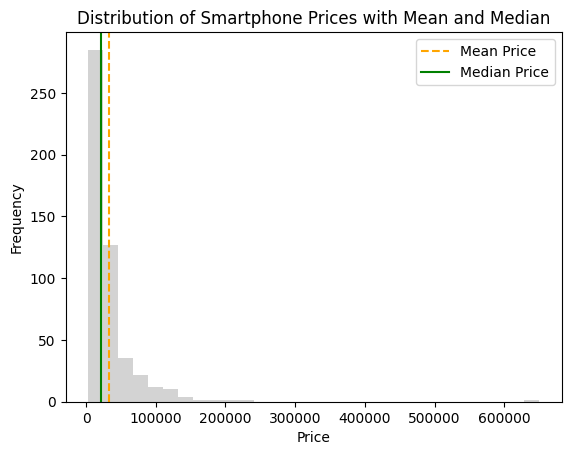

In [ ]:
fig, ax = plt.subplots()
plt.axvline(x = np.mean(mydata['price']), color='orange', linestyle='--', label='Mean Price')
plt.axvline(x = np.median(mydata['price']), color='green', linestyle='-', label='Median Price')
_ = plt.hist(mydata['price'], color = 'lightgray', bins=30)
plt.title('Distribution of Smartphone Prices with Mean and Median')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()
plt.show()

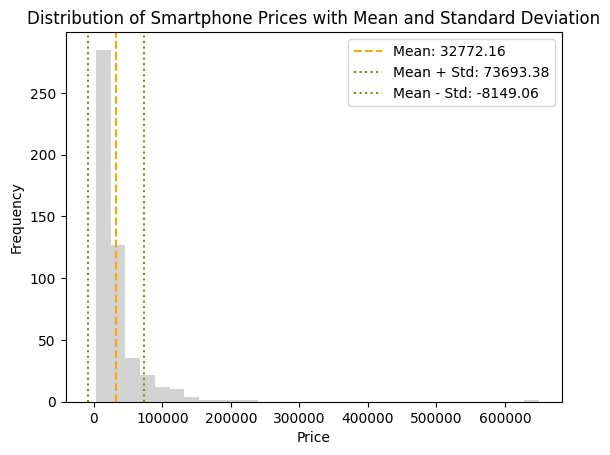

In [ ]:
fig, ax = plt.subplots()
xbar = np.mean(mydata['price'])
sigma = np.std(mydata['price'])
plt.axvline(x = xbar, color='orange', linestyle='--', label=f'Mean: {xbar:.2f}')
plt.axvline(x = xbar + sigma, color='olivedrab', linestyle=':', label=f'Mean + Std: {xbar+sigma:.2f}')
plt.axvline(x = xbar - sigma, color='olivedrab', linestyle=':', label=f'Mean - Std: {xbar-sigma:.2f}')
_ = plt.hist(mydata['price'], color = 'lightgray', bins=30)
plt.title('Distribution of Smartphone Prices with Mean and Standard Deviation')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
def sample_mean_calculator(data, sample_size, num_samples):
    sample_means = []
    for _ in range(num_samples):
        sample = np.random.choice(data, size=sample_size, replace=True)
        sample_means.append(np.mean(sample))
    return sample_means

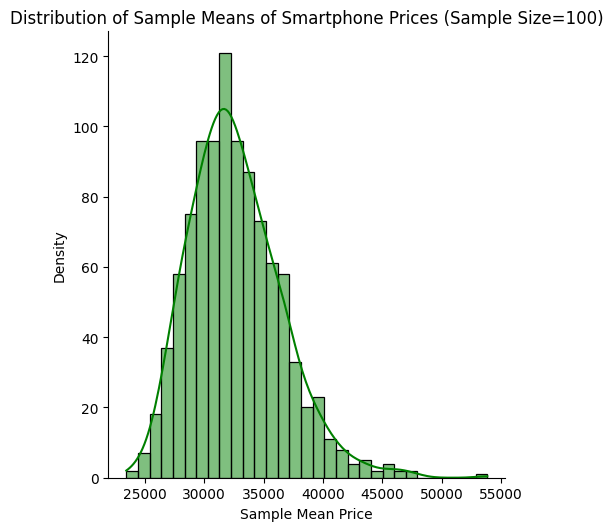

In [ ]:
sample_means = sample_mean_calculator(mydata['price'], sample_size=100, num_samples=1000)
sns.displot(sample_means, color='green', kde=True)
plt.title('Distribution of Sample Means of Smartphone Prices (Sample Size=100)')
plt.xlabel('Sample Mean Price')
plt.ylabel('Density')
plt.show()

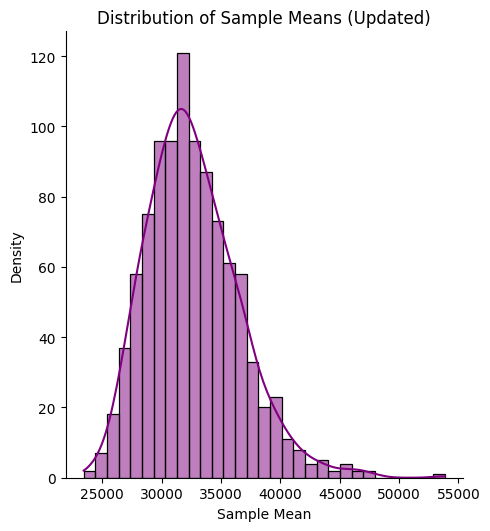

In [ ]:
sns.displot(sample_means, kde=True, color='purple') # Using sample_means and adding a color
plt.title('Distribution of Sample Means (Updated)')
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.show()

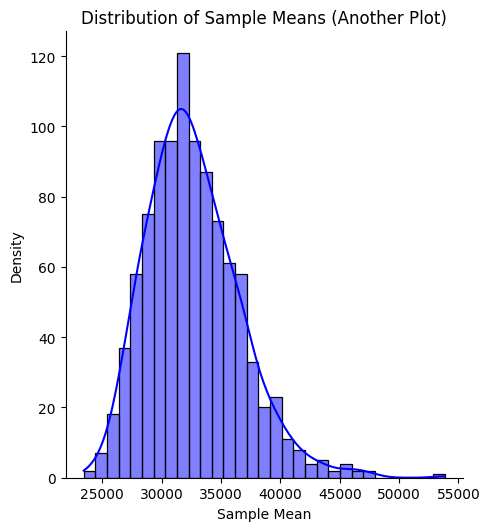

In [ ]:
sns.displot(sample_means, kde=True, color='blue')
plt.title('Distribution of Sample Means (Another Plot)')
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.show()

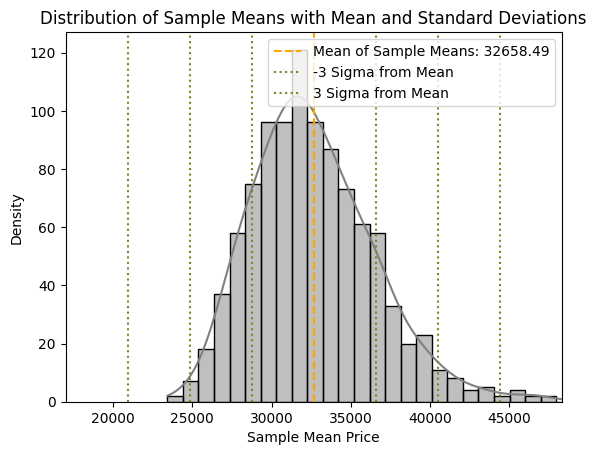

In [ ]:
fig, ax = plt.subplots()
mu_sample_means = np.mean(sample_means)
sigma_sample_means = np.std(sample_means)

sns.histplot(sample_means, kde=True, color='gray', ax=ax)
ax.set_xlim(mu_sample_means - 4 * sigma_sample_means, mu_sample_means + 4 * sigma_sample_means) # Adjust xlim based on sample means distribution
plt.axvline(mu_sample_means, color='orange', linestyle='--', label=f'Mean of Sample Means: {mu_sample_means:.2f}')
for v in [-3, -2, -1, 1, 2, 3]:
    plt.axvline(mu_sample_means + v * sigma_sample_means, color='olivedrab', linestyle=':', label=f'{v} Sigma from Mean' if v in [-3, 3] else "")

plt.title('Distribution of Sample Means with Mean and Standard Deviations')
plt.xlabel('Sample Mean Price')
plt.ylabel('Density')
plt.legend()
plt.show()

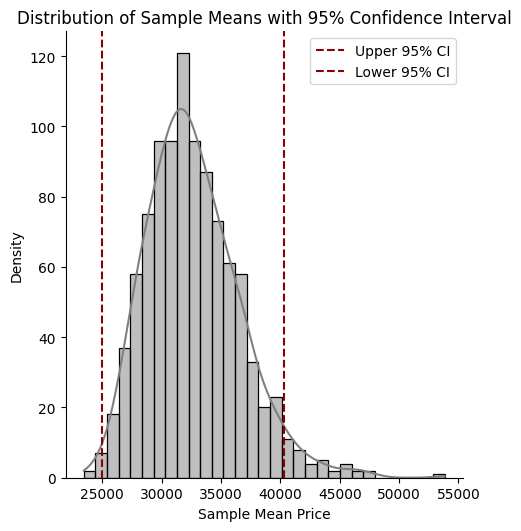

In [ ]:
sns.displot(sample_means, kde=True, color='gray')
plt.axvline(mu_sample_means + 1.96 * sigma_sample_means, color='darkred', linestyle='--', label='Upper 95% CI')
plt.axvline(mu_sample_means - 1.96 * sigma_sample_means, color='darkred', linestyle='--', label='Lower 95% CI')
plt.title('Distribution of Sample Means with 95% Confidence Interval')
plt.xlabel('Sample Mean Price')
plt.ylabel('Density')
plt.legend()
plt.show()

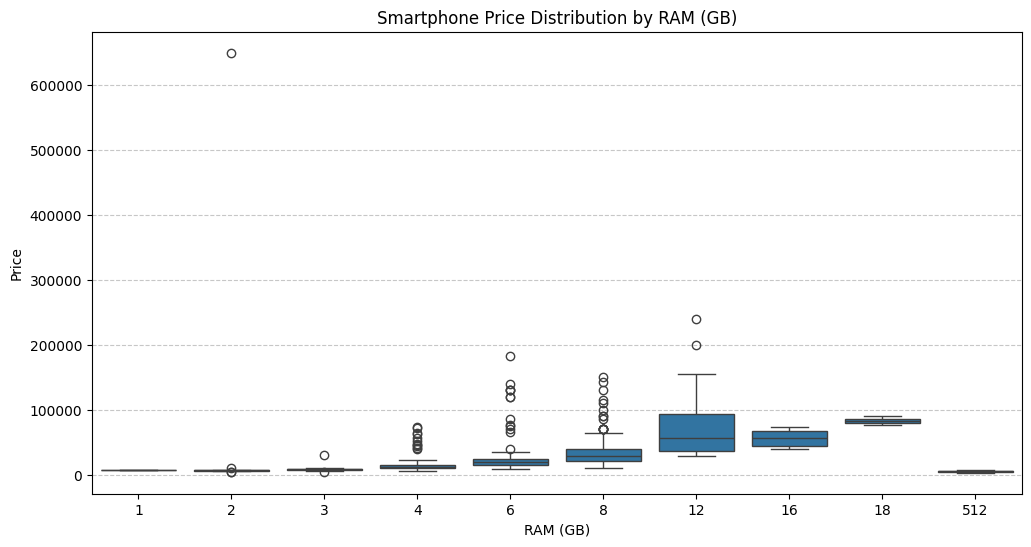

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='ram_gb', y='price', data=mydata)
plt.title('Smartphone Price Distribution by RAM (GB)')
plt.xlabel('RAM (GB)')
plt.ylabel('Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

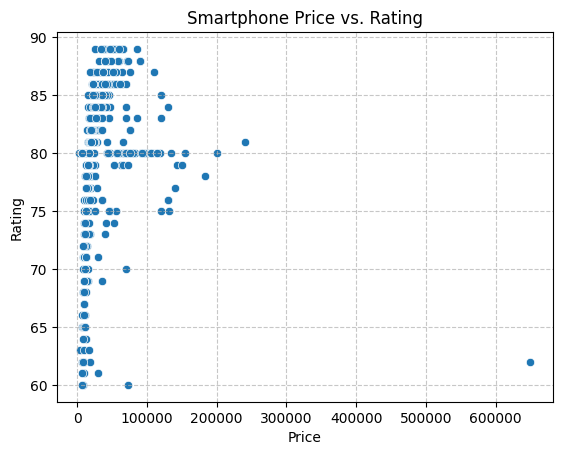

In [ ]:
sns.scatterplot(x='price', y='rating', data=mydata)
plt.title('Smartphone Price vs. Rating')
plt.xlabel('Price')
plt.ylabel('Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()